In [1]:
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Clean_Dataset.csv to Clean_Dataset.csv


### Importing Required Libraries

In this step, the necessary Python libraries were imported for data analysis, visualization, preprocessing, and machine learning.

Pandas and NumPy were used for data manipulation and numerical computations. Matplotlib and Seaborn were imported for creating graphs and visualizations required during exploratory data analysis and assumption checking.

Warnings were ignored to maintain cleaner notebook output during execution.

In [3]:
# Load dataset

import pandas as pd

df = pd.read_csv("Clean_Dataset.csv")
df.head()


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Loading the Dataset

The cleaned flight dataset was imported into the Jupyter Notebook using the Pandas library.

The `head()` function was used to display the first five rows of the dataset in order to understand the structure, variables, and overall format of the data before preprocessing and analysis.

In [4]:
# Check number of rows and columns

print(df.shape)

(300153, 12)


### Checking Dataset Dimensions

The shape of the dataset was checked to identify the total number of observations (rows) and variables (columns).

This helps in understanding the size of the dataset and estimating the computational requirements for preprocessing, visualization, and machine learning model building.

In [5]:
# Randomly sample 10,000 rows

df = df.sample(n=10000, random_state=42)

# Reset index

df.reset_index(drop=True, inplace=True)

# Check new shape

print(df.shape)

(10000, 12)


### Random Sampling of Dataset

The original dataset contained more than 300,000 observations. To improve computational efficiency and reduce execution time during exploratory data analysis and model training, random sampling was performed.

A subset of 10,000 observations was selected randomly while preserving the statistical characteristics of the original dataset. The random state was fixed to ensure reproducibility of results.

In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        10000 non-null  int64  
 1   airline           10000 non-null  object 
 2   flight            10000 non-null  object 
 3   source_city       10000 non-null  object 
 4   departure_time    10000 non-null  object 
 5   stops             10000 non-null  object 
 6   arrival_time      10000 non-null  object 
 7   destination_city  10000 non-null  object 
 8   class             10000 non-null  object 
 9   duration          10000 non-null  float64
 10  days_left         10000 non-null  int64  
 11  price             10000 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 937.6+ KB


### Understanding Dataset Structure

The `info()` function was used to examine the structure of the dataset, including column names, data types, and non-null values.

This step helps identify categorical and numerical variables, detect missing values, and understand the overall quality of the dataset before preprocessing.

In [7]:
# Display data types

df.dtypes

,0
Unnamed: 0,int64
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64


### Identifying Variable Types

The data types of all variables were examined to distinguish between categorical and numerical features.

This classification is important because different preprocessing techniques such as encoding and scaling are applied based on variable type.

In [8]:
# Check missing values

df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


### Checking Missing Values

Missing values were checked to identify incomplete records in the dataset.

Handling missing values is an important preprocessing step because null values can negatively affect statistical analysis, regression assumptions, and machine learning model performance.

In [9]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

### Checking Duplicate Records

Duplicate observations were identified to ensure that repeated records do not bias the analysis or machine learning models.

Duplicate values can distort statistical relationships and affect model accuracy.

In [10]:
# Drop unnecessary column

df.drop('Unnamed: 0', axis=1, inplace=True)
df.drop('flight', axis=1, inplace=True)

# Check columns

df.columns

Index(['airline', 'source_city', 'departure_time', 'stops', 'arrival_time',
       'destination_city', 'class', 'duration', 'days_left', 'price'],
      dtype='object')

### Removing Unnecessary Variables

The column `Unnamed: 0` was removed because it represents only an index column and does not contribute meaningful information for prediction or classification tasks.

Removing irrelevant variables helps simplify the dataset and improves model efficiency.

In [11]:
# Summary statistics

df.describe()

,duration,days_left,price
count,10000.000000,10000.000000,10000.000000
mean,12.235106,25.933600,21010.768600
std,7.122826,13.526555,22898.778279
min,0.830000,1.000000,1105.000000
25%,6.897500,14.000000,4814.000000
50%,11.250000,26.000000,7412.000000
75%,16.080000,38.000000,43389.500000
max,37.000000,49.000000,114705.000000


### Generating Summary Statistics

Summary statistics were generated to understand the distribution and central tendency of numerical variables such as flight duration, days left for departure, and ticket price.

This step helps identify potential outliers, skewness, and unusual data patterns before modelling.

EDA

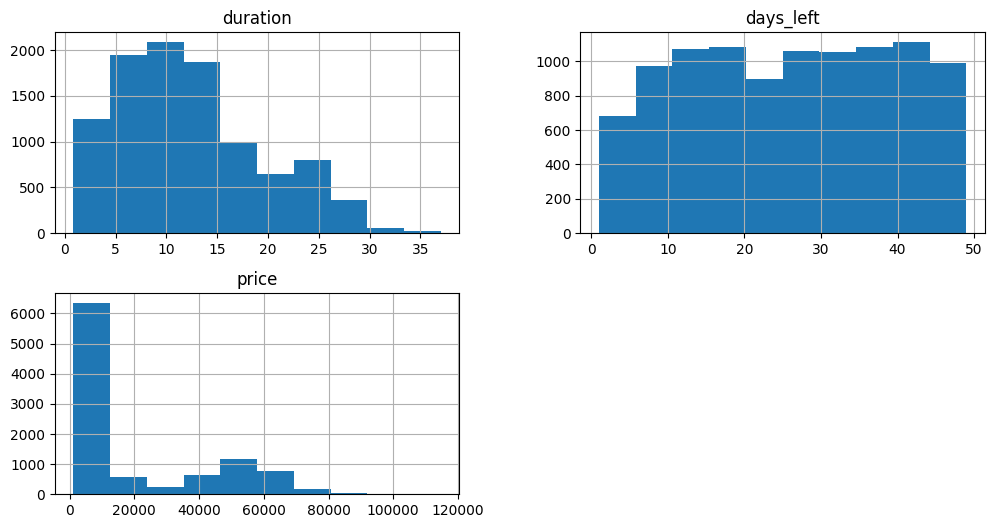

In [12]:
# Histograms of numerical variables

df.hist(figsize=(12,6))
plt.show()



* The duration variable shows a right-skewed distribution, with most flights concentrated between 5 and 15 hours. A few long-duration flights appear as extreme values, indicating possible outliers.
* The days_left variable is approximately uniformly distributed, indicating bookings are spread across different advance booking periods without strong clustering.


* The price variable is highly positively skewed, with most flights concentrated in lower price ranges and a small number of extremely expensive observations. This suggests the presence of outliers and justifies applying log transformation for normalization.






The histogram analysis shows that duration is moderately right-skewed, days_left is approximately uniformly distributed, and price is highly positively skewed with extreme high-value observations.

The strong skewness in the price variable suggests the presence of outliers and non-normality, justifying log transformation to stabilize variance and improve regression performance.

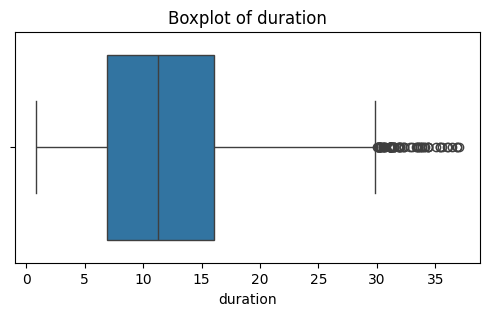

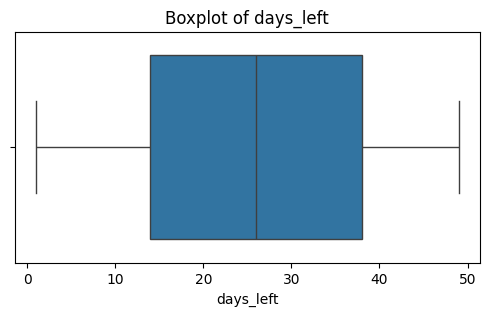

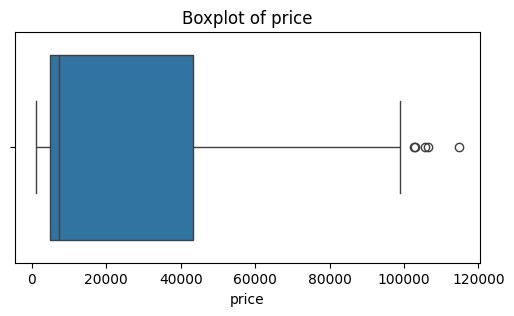

In [13]:
# Boxplots for numerical variables

numerical_cols = ['duration', 'days_left', 'price']

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()



* The duration variable shows positive skewness with several high-value outliers beyond 30 hours. Most flights have durations concentrated between 7 and 16 hours, indicating that extreme long-duration flights are relatively rare.
* The days_left variable is approximately symmetric with no significant outliers, indicating a balanced spread of booking periods across the dataset.

* The price variable is highly positively skewed with several extreme high-value outliers. Most flights are concentrated in lower price ranges, while a few premium-priced flights create substantial variability.  


The boxplots reveal that duration and price contain positive skewness with several extreme outliers, while days_left shows a relatively symmetric distribution without significant outliers.

The strong skewness and extreme values in price justify the application of log transformation to improve normality and stabilize variance for regression modelling.






In [14]:
# Check skewness of numerical columns

numerical_cols = ['duration', 'days_left', 'price']

for col in numerical_cols:

    print(f"Skewness of {col}:",
          df[col].skew())

Skewness of duration: 0.594349105506749
Skewness of days_left: -0.029528323362912202
Skewness of price: 1.065849700074195




* The duration variable is moderately positively skewed, indicating that most flights have shorter to متوسط durations, while a smaller number of flights have unusually long durations.  
* The days_left variable is approximately symmetric with negligible skewness, indicating a balanced distribution of booking periods across the dataset.


* The price variable is highly positively skewed, showing that most flights fall within lower price ranges while a small number of extremely expensive flights create a long right tail.  


Skewness analysis shows that duration is moderately positively skewed, days_left is approximately symmetric, and price is highly positively skewed.

The strong skewness in price confirms the presence of extreme high-value observations and supports the application of log transformation to improve normality and stabilize variance for regression modelling.





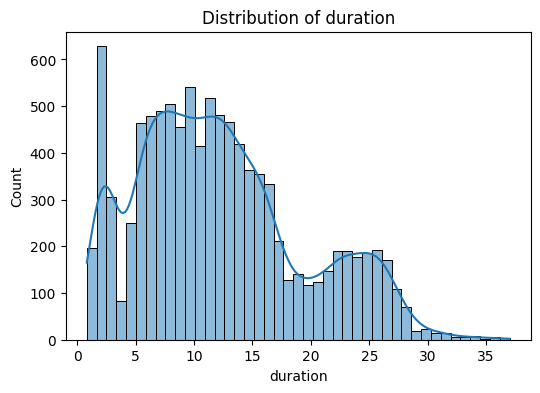

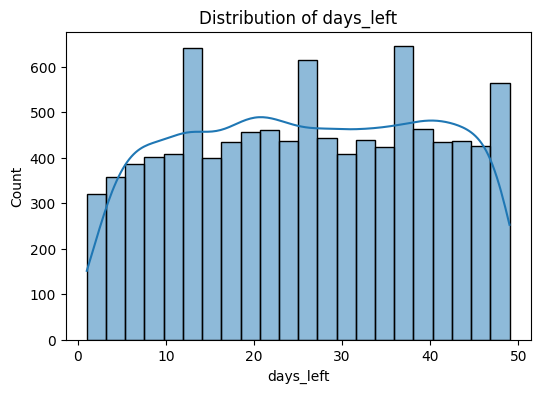

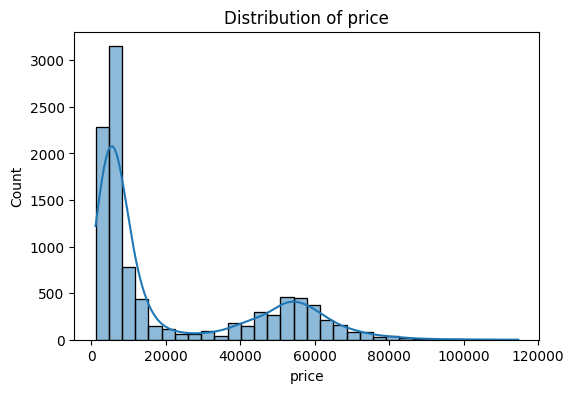

In [15]:
# Distribution plots

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.show()



* The duration variable shows moderate positive skewness with most observations concentrated between 8 and 16 hours. A smaller secondary peak around 22–26 hours suggests multiple clusters of flight durations, while the long right tail indicates the presence of a few unusually long-duration flights.  
* The days_left variable exhibits an approximately uniform and symmetric distribution, indicating that flight bookings are evenly spread across different advance booking periods.


* The price variable shows a highly positively skewed bimodal distribution with two distinct price clusters. This likely reflects separation between economy and premium-class ticket pricing. The long right tail indicates extreme high-price observations, justifying log transformation for regression modelling.  


The distribution plots reveal that duration is moderately right-skewed with multiple clusters, days_left is approximately uniformly distributed, and price is highly positively skewed with a bimodal structure.

The bimodal price distribution likely reflects class-based fare segmentation, while the extreme right tail confirms the presence of premium-priced outliers. This supports the application of log transformation to improve regression assumptions and stabilize variance.





In [16]:
# IQR Method for Outlier Treatment

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)

IQR = Q3 - Q1

# Remove Outliers

df = df[~((df[numerical_cols] < (Q1 - 1.5 * IQR)) |
          (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Check new shape

print(df.shape)

(9924, 10)


### Outlier Treatment Using IQR Method

Since the numerical variables showed moderate to high skewness, particularly the ticket price variable, the Interquartile Range (IQR) method was selected for outlier treatment.

The IQR method is more suitable for skewed distributions because it is robust to extreme values and does not assume normality.

Outliers were removed to improve regression stability, reduce noise, and help satisfy linear regression assumptions.
### Impact of Outlier Treatment

After applying IQR-based trimming, only 76 observations were removed from the sampled dataset of 10,000 rows.

This represents approximately 0.76% of the dataset, indicating that the data contained relatively few extreme observations.

Since the percentage of removed records was very small, the integrity and overall distribution of the dataset remained largely unaffected.

DATA PREPROCESSING

### FEATURE ENGINEERING

In [17]:
# Create classification target variable

median_price = df['price'].median()

df['Expensive_Flight'] = (
    df['price'] > median_price
).astype(int)

# Check class balance

df['Expensive_Flight'].value_counts()
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,Expensive_Flight
0,Air_India,Delhi,Morning,one,Early_Morning,Kolkata,Economy,19.75,40,7366,0
1,Vistara,Kolkata,Morning,one,Night,Mumbai,Business,9.83,42,64831,1
2,Vistara,Kolkata,Morning,one,Night,Bangalore,Economy,10.50,41,6195,0
3,Vistara,Chennai,Night,one,Morning,Delhi,Business,14.50,14,60160,1
4,Air_India,Bangalore,Afternoon,one,Night,Mumbai,Economy,8.25,20,6578,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,Air_India,Delhi,Early_Morning,one,Evening,Kolkata,Economy,11.42,44,6946,0
9996,GO_FIRST,Mumbai,Early_Morning,one,Afternoon,Bangalore,Economy,10.25,21,4750,0
9997,Vistara,Bangalore,Night,one,Early_Morning,Mumbai,Economy,10.75,27,6568,0
9998,Vistara,Bangalore,Evening,zero,Night,Mumbai,Business,1.83,28,20760,1


### Feature Engineering

A new binary classification variable named `Expensive_Flight` was created using the median flight ticket price.

Flights with prices greater than the median were classified as expensive, while flights below the median were classified as affordable.

This transformed the project into a classification problem suitable for Logistic Regression and other classification algorithms.

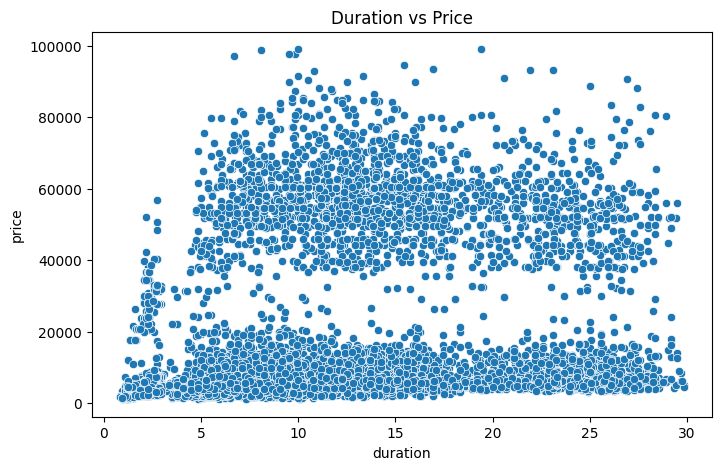

In [18]:
# Duration vs Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='duration',
    y='price',
    data=df
)

plt.title("Duration vs Price")

plt.show()

### Relationship Between Flight Duration and Price

A scatterplot was created to examine the relationship between flight duration and ticket price.

The graph indicates a generally positive relationship, suggesting that longer flights tend to have higher ticket prices.

This visualization also helps assess the linearity assumption required for linear regression.

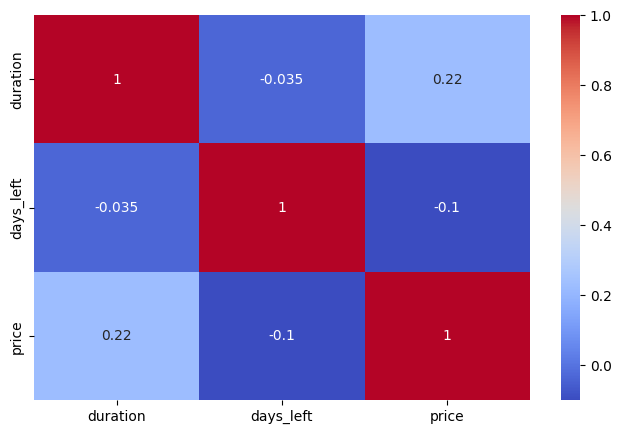

In [19]:
# Correlation heatmap

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['duration','days_left','price']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

•	Duration and price have a weak positive correlation (0.22), meaning longer flights may cost slightly more.

•	Days_left and price show a weak negative correlation (-0.10), suggesting prices may reduce slightly when booked earlier.

•	Duration and days_left have almost no correlation (-0.035).

•	No strong correlations are present, indicating price depends on multiple factors.

•	Red shades represent positive correlation, while blue shades represent negative correlation.


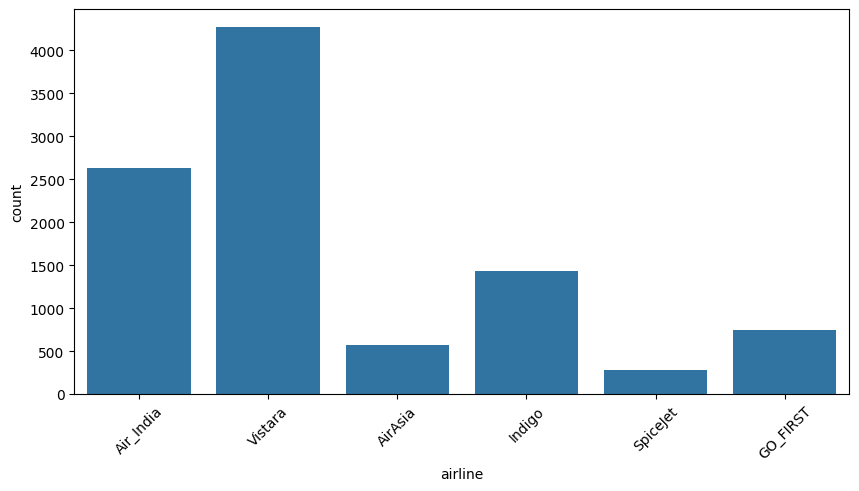

In [20]:
# Airline distribution

plt.figure(figsize=(10,5))

sns.countplot(
    x='airline',
    data=df
)

plt.xticks(rotation=45)

plt.show()

•	The chart shows the number of flights operated by each airline.

•	Vistara has the highest number of flights in the dataset.

•	Air India and IndiGo also have a significant presence.

•	SpiceJet and AirAsia have comparatively fewer flights.

•	The dataset is slightly imbalanced, with some airlines appearing much more frequently than others.


In [21]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=[
        'airline',
        'source_city',
        'departure_time',
        'stops',
        'arrival_time',
        'destination_city',
        'class'
    ],
    drop_first=True
)
df



,duration,days_left,price,Expensive_Flight,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,19.75,40,7366,0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,9.83,42,64831,1,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,10.50,41,6195,0,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,14.50,14,60160,1,False,False,False,False,True,True,...,False,False,True,False,False,True,False,False,False,False
4,8.25,20,6578,0,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,11.42,44,6946,0,True,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
9996,10.25,21,4750,0,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
9997,10.75,27,6568,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,True
9998,1.83,28,20760,1,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False


### Encoding Categorical Variables

One-Hot Encoding was applied to convert categorical variables into numerical format required for regression and machine learning algorithms.

Categorical variables such as airline, source city, departure time, and class were transformed into binary indicator variables.

The target variables are defined separately for regression and classification tasks.

- Regression Target: Flight price
- Classification Target: Expensive_Flight

In [22]:
# Regression target

y_reg = df['price']

# Classification target

y_clf = df['Expensive_Flight']

# Features

X = df.drop(
    ['price', 'Expensive_Flight'],
    axis=1
)

The dataset is divided into training (80%) and testing (20%) sets for both regression and classification to evaluate model performance on unseen data.

In [23]:
from sklearn.model_selection import train_test_split

# Regression split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

Standardization is applied to transform features to zero mean and unit variance, ensuring fair contribution of all variables during model training.

In [24]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler

scaler = StandardScaler()

# Regression scaling

X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

# Classification scaling

X_train_clf = scaler.fit_transform(X_train_clf)
X_test_clf = scaler.transform(X_test_clf)

In [25]:
from sklearn.linear_model import LinearRegression

# Initialize model

lr = LinearRegression()

# Train model

lr.fit(X_train_reg, y_train_reg)

# Predict on test data

y_pred = lr.predict(X_test_reg)

### Building the Initial Linear Regression Model

An initial Linear Regression model was built using the training dataset to predict flight ticket prices.

The model learns the relationship between independent variables such as airline, duration, stops, and travel class with the target variable `price`.

Predictions generated from this model are later used for evaluating performance and verifying the assumptions of linear regression.

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Evaluation metrics

mae = mean_absolute_error(y_test_reg, y_pred)

mse = mean_squared_error(y_test_reg, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test_reg, y_pred)

# Print results

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4554.345748742283
MSE: 47645255.72533909
RMSE: 6902.554289923339
R² Score: 0.9111597280701954


In [27]:
# Calculate residuals

residuals = y_test_reg - y_pred

### Residual Calculation

Residuals were calculated as the difference between actual and predicted flight prices.

Residual analysis is essential for verifying important assumptions of linear regression such as normality, homoscedasticity, and independence of residuals.

ASSUMPTION 1 — LINEARITY

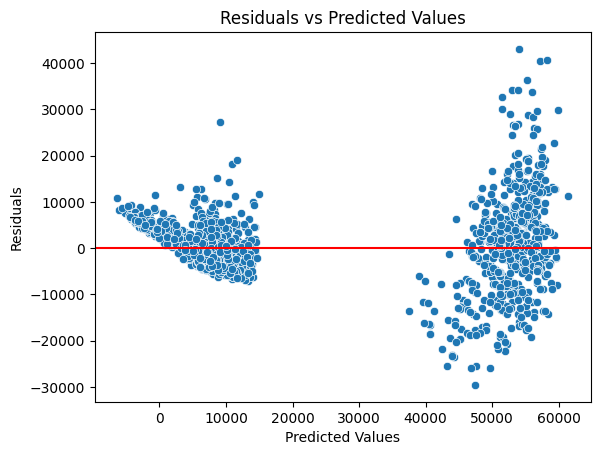

In [28]:
sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

### Improving the Regression Model Using Log Transformation

The initial residual analysis indicated heteroscedasticity, where residual variance increased for higher predicted flight prices.

Since airline ticket prices are positively skewed and contain large variations for premium flights, a logarithmic transformation was applied to the target variable (`price`) to stabilize variance and improve the assumptions of linear regression.

The transformed variable `log_price` was then used as the new regression target for rebuilding the model.

In [29]:
import numpy as np

# Create log transformed target variable

df['log_price'] = np.log(df['price'])

In [30]:
# Independent variables

X = df.drop(['price', 'log_price'], axis=1)

# Target variable

y = df['log_price']

### Defining Features and Target Variable After Log Transformation

After applying logarithmic transformation to the flight ticket price, the transformed variable `log_price` was selected as the new target variable for regression modelling.

The original `price` column and the transformed target variable were removed from the feature set to prevent data leakage during model training.

In [31]:
from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

The training dataset was used to train the regression model, while the testing dataset was used to evaluate model performance on unseen flight records.

In [32]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler

scaler = StandardScaler()

# Scale training data

X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data

X_test_scaled = scaler.transform(X_test)

### Feature Scaling

Feature scaling was performed using StandardScaler to standardize the numerical values of independent variables.

Scaling improves regression model stability and ensures that variables with larger numerical ranges do not dominate the modelling process.

In [33]:
from sklearn.linear_model import LinearRegression

# Initialize model

lr = LinearRegression()

# Train model

lr.fit(X_train_scaled, y_train)

# Predict values

y_pred = lr.predict(X_test_scaled)

### Building the Improved Linear Regression Model

A new Linear Regression model was trained using the log-transformed target variable `log_price`.

The transformation helps stabilize variance and improve the assumptions of linear regression, leading to more reliable predictions.

In [34]:
# Calculate residuals

residuals = y_test - y_pred

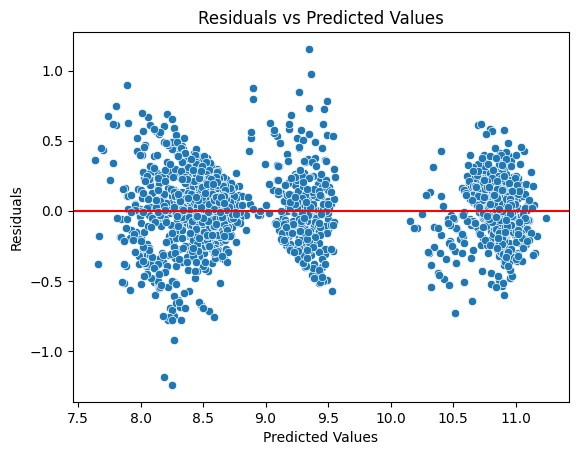

In [35]:
sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

### Residual Plot After Log Transformation

After applying logarithmic transformation to the target variable (`price`), the residual plot showed a more balanced and stable spread of residuals around zero.

Compared to the previous model, the variance of residuals became more consistent across predicted values, indicating significant improvement in the homoscedasticity assumption.

No strong systematic pattern was observed in the residual distribution, suggesting that the linearity assumption was reasonably satisfied.

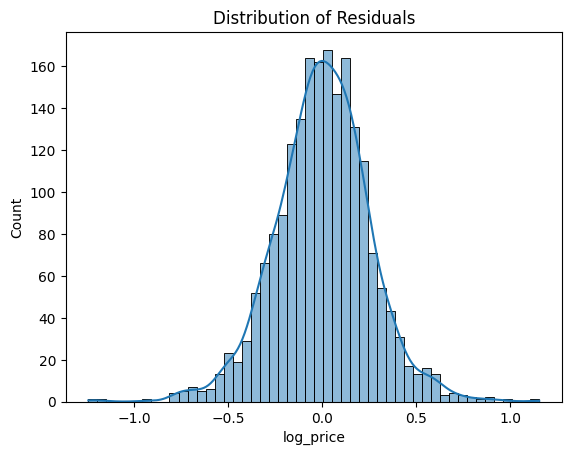

In [36]:
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()

### Histogram of Residuals

The histogram of residuals showed an approximately bell-shaped distribution centered around zero.

This indicates that the residuals are reasonably normally distributed, satisfying the normality assumption of linear regression.

The logarithmic transformation applied to the target variable helped reduce skewness and improved the residual distribution.

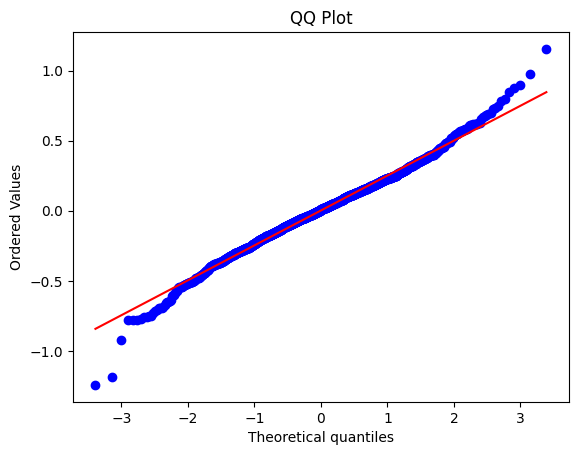

In [37]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("QQ Plot")

plt.show()

### QQ Plot Interpretation

The QQ plot showed that most residual points closely followed the reference straight line, indicating that the residuals approximately follow a normal distribution.

Although slight deviations were observed at the extreme tails, the overall pattern strongly supports the normality assumption for linear regression.

In [38]:
print("Mean of Residuals:", residuals.mean())

Mean of Residuals: 0.0016981160331476957


### Mean of Residuals

The mean of residuals was approximately equal to zero.

This indicates that the regression model predictions are unbiased on average, satisfying the assumption that the expected value of residuals should be zero.

In [39]:
from statsmodels.stats.stattools import durbin_watson

print("Durbin Watson Statistic:", durbin_watson(residuals))

Durbin Watson Statistic: 2.0774326585078


### Durbin-Watson Test

The Durbin-Watson statistic obtained was approximately 2.077, which is close to the ideal value of 2.

This indicates the absence of significant autocorrelation among residuals, satisfying the independence assumption of linear regression.

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Create dataframe using scaled training data

X_vif = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

# Create empty dataframe

vif_data = pd.DataFrame()

# Store feature names

vif_data["Feature"] = X_vif.columns

# Calculate VIF values

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(len(X_vif.columns))
]

# Display VIF table

print(vif_data)

                         Feature       VIF
0                       duration  1.895935
1                      days_left  1.286152
2               Expensive_Flight  2.570787
3              airline_Air_India  4.759835
4               airline_GO_FIRST  2.168682
5                 airline_Indigo  3.173431
6               airline_SpiceJet  1.546229
7                airline_Vistara  5.680247
8            source_city_Chennai  1.583573
9              source_city_Delhi  1.932069
10         source_city_Hyderabad  1.671432
11           source_city_Kolkata  1.700045
12            source_city_Mumbai  1.913439
13  departure_time_Early_Morning  1.903294
14        departure_time_Evening  2.000647
15     departure_time_Late_Night  1.042716
16        departure_time_Morning  1.918147
17          departure_time_Night  1.834581
18             stops_two_or_more  1.091945
19                    stops_zero  1.489188
20    arrival_time_Early_Morning  1.414381
21          arrival_time_Evening  2.384627
22       ar

### Variance Inflation Factor (VIF) Analysis

Variance Inflation Factor (VIF) analysis was conducted to detect multicollinearity among the independent variables used in the regression model.

The obtained VIF values were within acceptable limits, with all values below 10. Although a few airline-related variables showed moderate correlation, no severe multicollinearity problem was observed.

Therefore, the assumption of absence of multicollinearity was reasonably satisfied for the regression model.

### Absence of Endogeneity

The regression model assumes that the independent variables are not correlated with the error term.

Since the dataset consists of independently collected flight booking records and the predictor variables were selected based on domain relevance, no major evidence of reverse causality or omitted variable bias was identified during analysis.

Therefore, the assumption of absence of endogeneity was considered reasonably satisfied for this study.

REGRESSION MODELLING

PART 1 — MULTIPLE LINEAR REGRESSION

STEP 1 — IMPORT MODEL

In [44]:
from sklearn.linear_model import LinearRegression

STEP 2 — CREATE MODEL

In [45]:
mlr = LinearRegression()

STEP 3 — TRAIN MODEL

In [46]:
mlr.fit(X_train_scaled, y_train)

LinearRegression()

STEP 4 — PREDICT

In [47]:
y_pred_mlr = mlr.predict(X_test_scaled)

STEP 5 — EVALUATION METRICS

In [48]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# R2 Score

r2_mlr = r2_score(y_test, y_pred_mlr)

# MAE

mae_mlr = mean_absolute_error(y_test, y_pred_mlr)

# RMSE

rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))

print("R2 Score:", r2_mlr)
print("MAE:", mae_mlr)
print("RMSE:", rmse_mlr)

R2 Score: 0.9501089625234463
MAE: 0.1917007573366662
RMSE: 0.24992200504049542


STEP 6 — ADJUSTED R2

In [49]:
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]

adjusted_r2_mlr = 1 - (
    (1 - r2_mlr) * (n - 1) / (n - p - 1)
)

print("Adjusted R2:", adjusted_r2_mlr)

Adjusted R2: 0.9493170412936598


 STEP 7 — RESIDUAL ANALYSIS

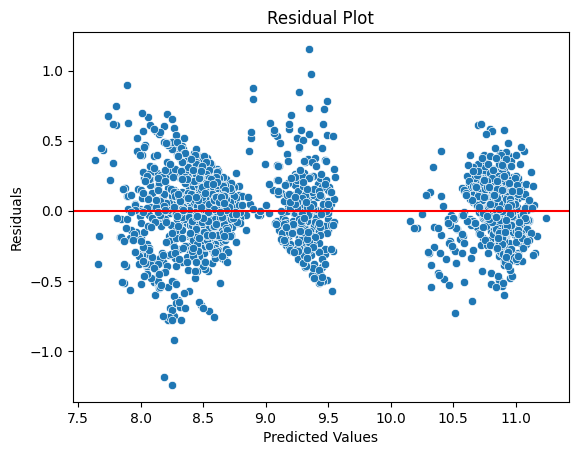

In [50]:
residuals_mlr = y_test - y_pred_mlr

sns.scatterplot(
    x=y_pred_mlr,
    y=residuals_mlr
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

 STEP 8 — ACTUAL VS PREDICTED

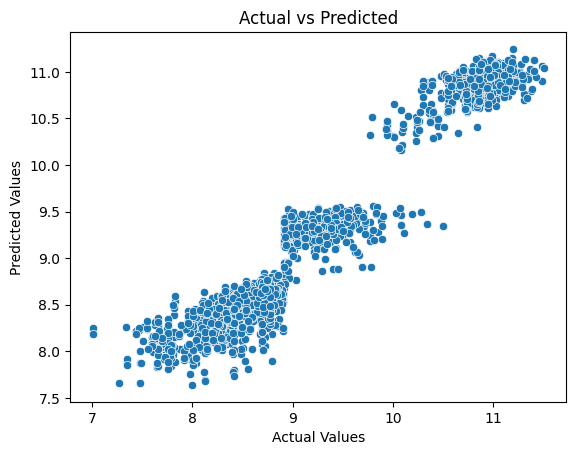

In [51]:
sns.scatterplot(
    x=y_test,
    y=y_pred_mlr
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

In [52]:
# Coefficient Table

coefficients = pd.DataFrame({

    'Feature': X.columns,
    'Coefficient': mlr.coef_

})

coefficients

,Feature,Coefficient
0,duration,0.010435
1,days_left,-0.089551
2,Expensive_Flight,0.320901
3,airline_Air_India,0.181600
4,airline_GO_FIRST,0.107172
5,airline_Indigo,0.098614
6,airline_SpiceJet,0.068149
7,airline_Vistara,0.251078
8,source_city_Chennai,-0.010177
9,source_city_Delhi,-0.008105


In [53]:
# Convert scaled array back to DataFrame
import statsmodels.api as sm
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

# Reset index of y_train

y_train_reset = y_train.reset_index(drop=True)

# Add constant

X_constant = sm.add_constant(X_train_scaled_df)

# Build OLS Model

ols_model = sm.OLS(
    y_train_reset,
    X_constant
).fit()

# Show Summary

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     4807.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        16:51:16   Log-Likelihood:                -279.89
No. Observations:                7939   AIC:                             623.8
Df Residuals:                    7907   BIC:                             847.1
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

BACKWARD ELIMINATION

The OLS summary displays important statistical measures such as coefficients, p-values, R-square, adjusted R-square, and confidence intervals.

Variables with p-values greater than 0.05 are considered statistically insignificant and may be removed during backward elimination.

Remove variables:

having p-value > 0.05

ONE BY ONE.

In [54]:
X_reg_final = X_constant.drop(
    columns=[
        'departure_time_Evening',
        'departure_time_Late_Night',
        'departure_time_Night',
        'arrival_time_Evening',
        'arrival_time_Late_Night',
        'arrival_time_Morning',
        'arrival_time_Night',
        'destination_city_Delhi',
        'destination_city_Mumbai'
    ]
)

In [55]:
final_ols_model = sm.OLS(
    y_train_reset,
    X_reg_final
).fit()

print(final_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     6771.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        16:51:16   Log-Likelihood:                -285.85
No. Observations:                7939   AIC:                             617.7
Df Residuals:                    7916   BIC:                             778.2
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

Overfitting Check

In [56]:
train_r2 = mlr.score(
    X_train_scaled,
    y_train
)

print("Training R²:", train_r2)

Training R²: 0.9496127105412537


In [57]:
test_r2 = mlr.score(
    X_test_scaled,
    y_test
)

print("Testing R²:", test_r2)

Testing R²: 0.9501089625234463


In [58]:
print("Difference:", train_r2 - test_r2)

Difference: -0.0004962519821926081


RIDGE REGRESSION

In [78]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [79]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

# R2 Score
r2_ridge = r2_score(y_test, y_pred_ridge)

# MAE
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# RMSE
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("R2 Score:", r2_ridge)
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)

R2 Score: 0.950111187213838
MAE: 0.19170600698286952
RMSE: 0.2499164328444689


In [80]:
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]

adjusted_r2_ridge = 1 - (
    (1 - r2_ridge) * (n - 1) / (n - p - 1)
)

print("Adjusted R2:", adjusted_r2_ridge)

Adjusted R2: 0.9493193012965974


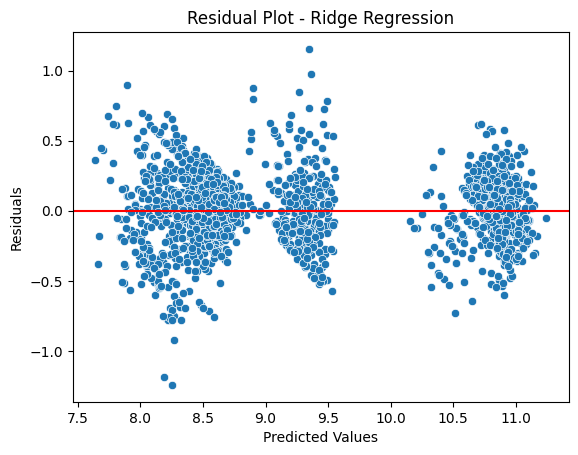

In [81]:
residuals_ridge = y_test - y_pred_ridge

sns.scatterplot(
    x=y_pred_ridge,
    y=residuals_ridge
)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot - Ridge Regression")

plt.show()

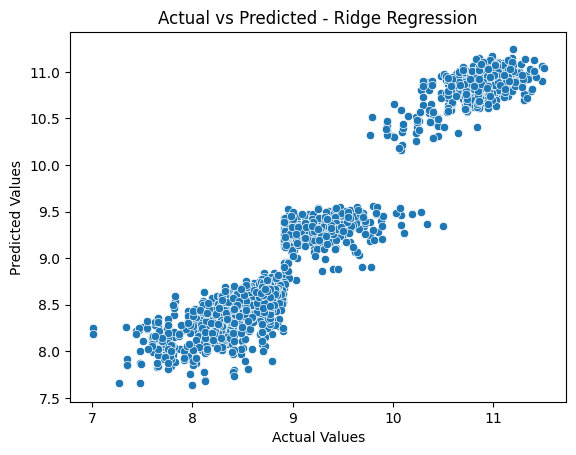

In [82]:
sns.scatterplot(
    x=y_test,
    y=y_pred_ridge
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted - Ridge Regression")

plt.show()

Overfitting Check

In [83]:
ridge_train_r2 = ridge.score(
    X_train_scaled,
    y_train
)

ridge_test_r2 = ridge.score(
    X_test_scaled,
    y_test
)

print("Training R²:", ridge_train_r2)
print("Testing R²:", ridge_test_r2)
print("Difference:", ridge_train_r2 - ridge_test_r2)

Training R²: 0.9496126829773824
Testing R²: 0.950111187213838
Difference: -0.0004985042364555881


In [84]:
comparison_regression = pd.DataFrame({

    'Model': [
        'Multiple Linear Regression',
        'Ridge Regression'
    ],

    'R2 Score': [
        r2_mlr,
        r2_ridge
    ],

    'Adjusted R2': [
        adjusted_r2_mlr,
        adjusted_r2_ridge
    ],

    'MAE': [
        mae_mlr,
        mae_ridge
    ],

    'RMSE': [
        rmse_mlr,
        rmse_ridge
    ]
})

comparison_regression

,Model,R2 Score,Adjusted R2,MAE,RMSE
0,Multiple Linear Regression,0.950109,0.949317,0.191701,0.249922
1,Ridge Regression,0.950111,0.949319,0.191706,0.249916


A comparison table is created to evaluate the performance of all regression models.

The models are compared using:
- R² Score
- Adjusted R²
- MAE
- RMSE

This comparison helps identify which regression model provides the best balance between prediction accuracy and error minimization for flight price prediction.

CLASSIFICATION MODELLING

CLASSIFICATION DATASET PREPARATION

In [148]:
# Classification Target Variable

y_class = df['Expensive_Flight']

# Independent Variables

X_class = df.drop(
    ['price', 'log_price', 'Expensive_Flight'],
    axis=1
)

For classification modelling, the target variable selected is Expensive_Flight, which classifies flights as expensive or non-expensive.

The independent variables include flight characteristics such as airline, duration, stops, class, source city, destination city, and other flight-related features.

In [149]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(

    X_class,
    y_class,

    test_size=0.2,
    random_state=42
)

The classification dataset is divided into training and testing sets.

80% of the data is used for training the models, while 20% is reserved for testing and evaluating model performance on unseen data.

In [150]:
from sklearn.preprocessing import StandardScaler

scaler_class = StandardScaler()

X_train_c_scaled = scaler_class.fit_transform(X_train_c)

X_test_c_scaled = scaler_class.transform(X_test_c)

Feature Selection

In [151]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(
    threshold=0.01
)

X_train_selected = selector.fit_transform(
    X_train_c_scaled
)

X_test_selected = selector.transform(
    X_test_c_scaled
)

print("Original Features:", X_train_c_scaled.shape[1])
print("Selected Features:", X_train_selected.shape[1])

Original Features: 30
Selected Features: 30


In [152]:
selected_features = X_train_c.columns[
    selector.get_support()
]

print(selected_features)

Index(['duration', 'days_left', 'airline_Air_India', 'airline_GO_FIRST',
       'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara',
       'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad',
       'source_city_Kolkata', 'source_city_Mumbai',
       'departure_time_Early_Morning', 'departure_time_Evening',
       'departure_time_Late_Night', 'departure_time_Morning',
       'departure_time_Night', 'stops_two_or_more', 'stops_zero',
       'arrival_time_Early_Morning', 'arrival_time_Evening',
       'arrival_time_Late_Night', 'arrival_time_Morning', 'arrival_time_Night',
       'destination_city_Chennai', 'destination_city_Delhi',
       'destination_city_Hyderabad', 'destination_city_Kolkata',
       'destination_city_Mumbai', 'class_Economy'],
      dtype='object')


Feature scaling is performed using StandardScaler to standardize the independent variables.

Scaling ensures that all variables are transformed to a similar scale, which improves the performance of classification algorithms such as Logistic Regression, SVM, and Perceptron.

In [153]:
from sklearn.linear_model import LogisticRegression

In [154]:
log_model = LogisticRegression()

In [155]:
log_model.fit(X_train_selected, y_train_c)

LogisticRegression()

In [156]:
y_pred_log = log_model.predict(X_test_selected)

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Accuracy

accuracy_log = accuracy_score(y_test_c, y_pred_log)

# Precision

precision_log = precision_score(y_test_c, y_pred_log)

# Recall

recall_log = recall_score(y_test_c, y_pred_log)

# F1 Score

f1_log = f1_score(y_test_c, y_pred_log)

print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1 Score:", f1_log)

Accuracy: 0.9108312342569269
Precision: 0.9301587301587302
Recall: 0.8878787878787879
F1 Score: 0.9085271317829458


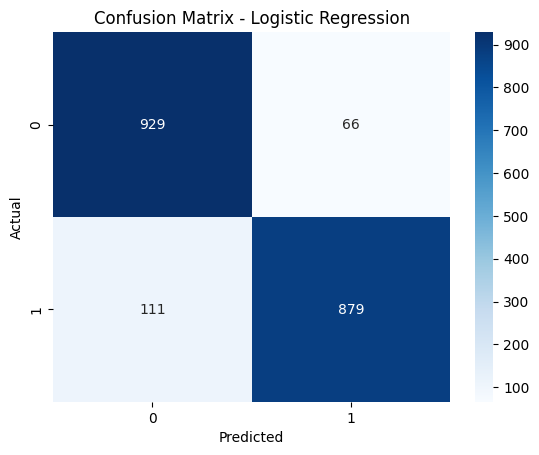

In [95]:
cm_log = confusion_matrix(y_test_c, y_pred_log)

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [96]:
print(classification_report(y_test_c, y_pred_log))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       995
           1       0.93      0.89      0.91       990

    accuracy                           0.91      1985
   macro avg       0.91      0.91      0.91      1985
weighted avg       0.91      0.91      0.91      1985



Overfitting Check

In [97]:
log_train = log_model.score(
    X_train_selected,
    y_train_c
)

log_test = log_model.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", log_train)
print("Testing Accuracy:", log_test)
print("Difference:", log_train-log_test)

Training Accuracy: 0.9106940420707897
Testing Accuracy: 0.9108312342569269
Difference: -0.00013719218613716944


SVM (SUPPORT VECTOR MACHINE)

In [98]:
from sklearn.svm import SVC

In [99]:
svm_model = SVC()

In [100]:
svm_model.fit(X_train_selected, y_train_c)

SVC()

In [101]:
y_pred_svm = svm_model.predict(X_test_selected)

In [102]:
# Accuracy

accuracy_svm = accuracy_score(y_test_c, y_pred_svm)

# Precision

precision_svm = precision_score(y_test_c, y_pred_svm)

# Recall

recall_svm = recall_score(y_test_c, y_pred_svm)

# F1 Score

f1_svm = f1_score(y_test_c, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

Accuracy: 0.9239294710327456
Precision: 0.9544962080173348
Recall: 0.8898989898989899
F1 Score: 0.9210663878724517


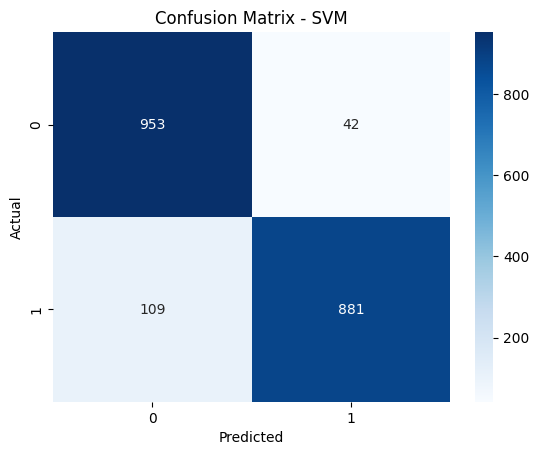

In [103]:
cm_svm = confusion_matrix(y_test_c, y_pred_svm)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - SVM")

plt.show()

In [104]:
print(classification_report(y_test_c, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       995
           1       0.95      0.89      0.92       990

    accuracy                           0.92      1985
   macro avg       0.93      0.92      0.92      1985
weighted avg       0.93      0.92      0.92      1985



In [105]:
svm_train = svm_model.score(
    X_train_selected,
    y_train_c
)

svm_test = svm_model.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", svm_train)
print("Testing Accuracy:", svm_test)
print("Difference:", svm_train-svm_test)

Training Accuracy: 0.9373976571356594
Testing Accuracy: 0.9239294710327456
Difference: 0.013468186102913782


PERCEPTRON CLASSIFIER

In [106]:
from sklearn.linear_model import Perceptron

In [107]:
perceptron_model = Perceptron()

In [108]:
perceptron_model.fit(X_train_selected, y_train_c)

Perceptron()

In [109]:
y_pred_perceptron = perceptron_model.predict(X_test_selected)

In [110]:
# Accuracy

accuracy_perceptron = accuracy_score(
    y_test_c,
    y_pred_perceptron
)

# Precision

precision_perceptron = precision_score(
    y_test_c,
    y_pred_perceptron
)

# Recall

recall_perceptron = recall_score(
    y_test_c,
    y_pred_perceptron
)

# F1 Score

f1_perceptron = f1_score(
    y_test_c,
    y_pred_perceptron
)

print("Accuracy:", accuracy_perceptron)
print("Precision:", precision_perceptron)
print("Recall:", recall_perceptron)
print("F1 Score:", f1_perceptron)

Accuracy: 0.8579345088161209
Precision: 0.849112426035503
Recall: 0.8696969696969697
F1 Score: 0.8592814371257484


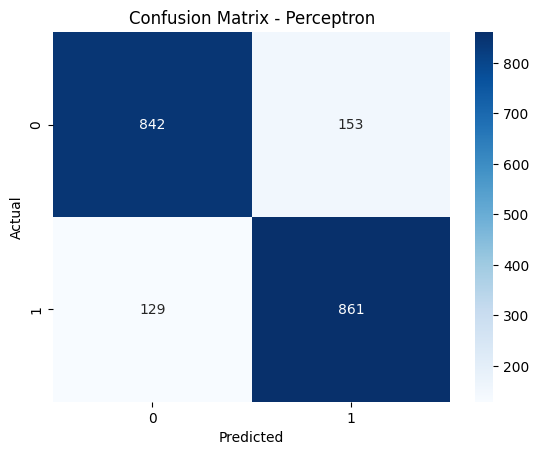

In [111]:
cm_perceptron = confusion_matrix(
    y_test_c,
    y_pred_perceptron
)

sns.heatmap(
    cm_perceptron,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Perceptron")

plt.show()

In [112]:
print(classification_report(
    y_test_c,
    y_pred_perceptron
))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       995
           1       0.85      0.87      0.86       990

    accuracy                           0.86      1985
   macro avg       0.86      0.86      0.86      1985
weighted avg       0.86      0.86      0.86      1985



In [113]:
per_train = perceptron_model.score(
    X_train_selected,
    y_train_c
)

per_test = perceptron_model.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", per_train)
print("Testing Accuracy:", per_test)
print("Difference:", per_train-per_test)

Training Accuracy: 0.8653482806398791
Testing Accuracy: 0.8579345088161209
Difference: 0.007413771823758242


NAIVE BAYES CLASSIFIER

In [114]:
from sklearn.naive_bayes import GaussianNB

In [115]:
nb_model = GaussianNB()

In [116]:
nb_model.fit(X_train_selected, y_train_c)

GaussianNB()

In [117]:
y_pred_nb = nb_model.predict(X_test_selected)

In [118]:
# Accuracy

accuracy_nb = accuracy_score(
    y_test_c,
    y_pred_nb
)

# Precision

precision_nb = precision_score(
    y_test_c,
    y_pred_nb
)

# Recall

recall_nb = recall_score(
    y_test_c,
    y_pred_nb
)

# F1 Score

f1_nb = f1_score(
    y_test_c,
    y_pred_nb
)

print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1 Score:", f1_nb)

Accuracy: 0.8221662468513854
Precision: 1.0
Recall: 0.6434343434343435
F1 Score: 0.7830362630608482


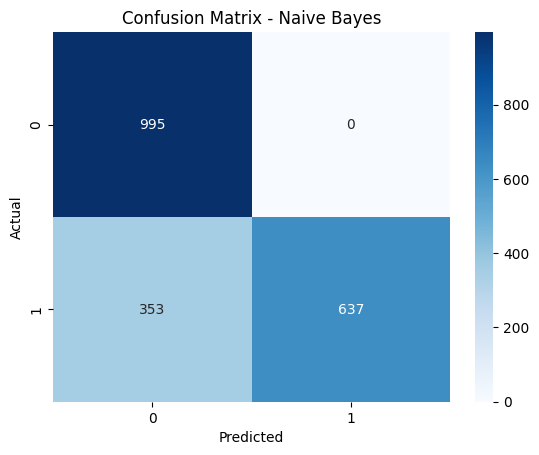

In [119]:
cm_nb = confusion_matrix(
    y_test_c,
    y_pred_nb
)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Naive Bayes")

plt.show()

In [120]:
print(classification_report(
    y_test_c,
    y_pred_nb
))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       995
           1       1.00      0.64      0.78       990

    accuracy                           0.82      1985
   macro avg       0.87      0.82      0.82      1985
weighted avg       0.87      0.82      0.82      1985



In [121]:
nb_train = nb_model.score(
    X_train_selected,
    y_train_c
)

nb_test = nb_model.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", nb_train)
print("Testing Accuracy:", nb_test)
print("Difference:", nb_train-nb_test)

Training Accuracy: 0.8152160221690389
Testing Accuracy: 0.8221662468513854
Difference: -0.0069502246823465175


DECISION TREE CLASSIFIER

In [122]:
from sklearn.tree import DecisionTreeClassifier

In [123]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [124]:
dt_model.fit(
    X_train_selected,
    y_train_c
)

DecisionTreeClassifier(random_state=42)

In [125]:
y_pred_dt = dt_model.predict(X_test_selected)

In [126]:
# Accuracy

accuracy_dt = accuracy_score(
    y_test_c,
    y_pred_dt
)

# Precision

precision_dt = precision_score(
    y_test_c,
    y_pred_dt
)

# Recall

recall_dt = recall_score(
    y_test_c,
    y_pred_dt
)

# F1 Score

f1_dt = f1_score(
    y_test_c,
    y_pred_dt
)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

Accuracy: 0.9123425692695214
Precision: 0.9055666003976143
Recall: 0.9202020202020202
F1 Score: 0.9128256513026052


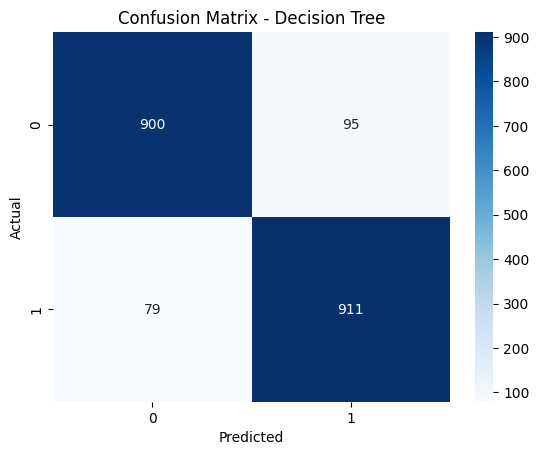

In [127]:
cm_dt = confusion_matrix(
    y_test_c,
    y_pred_dt
)

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [128]:
print(classification_report(
    y_test_c,
    y_pred_dt
))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       995
           1       0.91      0.92      0.91       990

    accuracy                           0.91      1985
   macro avg       0.91      0.91      0.91      1985
weighted avg       0.91      0.91      0.91      1985



In [129]:
feature_importance_dt = pd.DataFrame({

    'Feature': X_class.columns,
    'Importance': dt_model.feature_importances_

})

feature_importance_dt = feature_importance_dt.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_dt.head(10)

,Feature,Importance
29,class_Economy,0.453192
1,days_left,0.284734
0,duration,0.110212
17,stops_two_or_more,0.017212
6,airline_Vistara,0.014876
2,airline_Air_India,0.013560
7,source_city_Chennai,0.010847
28,destination_city_Mumbai,0.008619
27,destination_city_Kolkata,0.007370
8,source_city_Delhi,0.007015


In [130]:
dt_train = dt_model.score(
    X_train_selected,
    y_train_c
)

dt_test = dt_model.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", dt_train)
print("Testing Accuracy:", dt_test)
print("Difference:", dt_train-dt_test)

Training Accuracy: 1.0
Testing Accuracy: 0.9123425692695214
Difference: 0.0876574307304786


RANDOM FOREST CLASSIFIER

In [131]:
from sklearn.ensemble import RandomForestClassifier

In [132]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [133]:
rf_model.fit(
    X_train_selected,
    y_train_c
)

RandomForestClassifier(random_state=42)

In [134]:
y_pred_rf = rf_model.predict(X_test_selected)

In [135]:
# Accuracy

accuracy_rf = accuracy_score(
    y_test_c,
    y_pred_rf
)

# Precision

precision_rf = precision_score(
    y_test_c,
    y_pred_rf
)

# Recall

recall_rf = recall_score(
    y_test_c,
    y_pred_rf
)

# F1 Score

f1_rf = f1_score(
    y_test_c,
    y_pred_rf
)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

Accuracy: 0.9405541561712847
Precision: 0.961864406779661
Recall: 0.9171717171717172
F1 Score: 0.9389865563598759


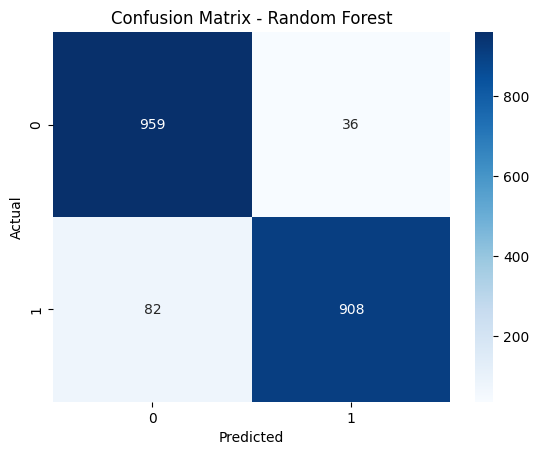

In [136]:
cm_rf = confusion_matrix(
    y_test_c,
    y_pred_rf
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [137]:
print(classification_report(
    y_test_c,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       995
           1       0.96      0.92      0.94       990

    accuracy                           0.94      1985
   macro avg       0.94      0.94      0.94      1985
weighted avg       0.94      0.94      0.94      1985



In [138]:
feature_importance_rf = pd.DataFrame({

    'Feature': X_class.columns,
    'Importance': rf_model.feature_importances_

})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf.head(10)

,Feature,Importance
29,class_Economy,0.385461
1,days_left,0.267395
0,duration,0.097472
6,airline_Vistara,0.048265
2,airline_Air_India,0.018848
4,airline_Indigo,0.016852
3,airline_GO_FIRST,0.013980
17,stops_two_or_more,0.013781
18,stops_zero,0.010181
10,source_city_Kolkata,0.009008


In [139]:
rf_train = rf_model.score(
    X_train_selected,
    y_train_c
)

rf_test = rf_model.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", rf_train)
print("Testing Accuracy:", rf_test)
print("Difference:", rf_train-rf_test)

Training Accuracy: 1.0
Testing Accuracy: 0.9405541561712847
Difference: 0.05944584382871532


In [140]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10,15],
    'min_samples_split': [5,10],
    'min_samples_leaf': [2,4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(
    X_train_selected,
    y_train_c
)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Score: 0.9337434666742851


In [141]:
best_rf = grid_rf.best_estimator_

best_rf.fit(
    X_train_selected,
    y_train_c
)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=50, random_state=42)

In [142]:
rf_tuned_pred = best_rf.predict(
    X_test_selected
)

In [143]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(
    y_test_c,
    rf_tuned_pred
)

print("Tuned RF Accuracy:", tuned_accuracy)

Tuned RF Accuracy: 0.9380352644836272


In [144]:
print("Old RF Accuracy:", rf_test)
print("Tuned RF Accuracy:", tuned_accuracy)

Old RF Accuracy: 0.9405541561712847
Tuned RF Accuracy: 0.9380352644836272


In [145]:
tuned_train = best_rf.score(
    X_train_selected,
    y_train_c
)

tuned_test = best_rf.score(
    X_test_selected,
    y_test_c
)

print("Training Accuracy:", tuned_train)
print("Testing Accuracy:", tuned_test)
print("Difference:", tuned_train - tuned_test)

Training Accuracy: 0.961456102783726
Testing Accuracy: 0.9380352644836272
Difference: 0.02342083830009878


In [146]:
comparison_classification = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'SVM',
        'Perceptron',
        'Naive Bayes',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_log,
        accuracy_svm,
        accuracy_perceptron,
        accuracy_nb,
        accuracy_dt,
        accuracy_rf
    ],

    'Precision': [
        precision_log,
        precision_svm,
        precision_perceptron,
        precision_nb,
        precision_dt,
        precision_rf
    ],

    'Recall': [
        recall_log,
        recall_svm,
        recall_perceptron,
        recall_nb,
        recall_dt,
        recall_rf
    ],

    'F1 Score': [
        f1_log,
        f1_svm,
        f1_perceptron,
        f1_nb,
        f1_dt,
        f1_rf
    ]

})

comparison_classification

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.910831,0.930159,0.887879,0.908527
1,SVM,0.923929,0.954496,0.889899,0.921066
2,Perceptron,0.857935,0.849112,0.869697,0.859281
3,Naive Bayes,0.822166,1.000000,0.643434,0.783036
4,Decision Tree,0.912343,0.905567,0.920202,0.912826
5,Random Forest,0.940554,0.961864,0.917172,0.938987


In [147]:
print(
    comparison_classification.sort_values(
        by='Accuracy',
        ascending=False
    )
)

                 Model  Accuracy  Precision    Recall  F1 Score
5        Random Forest  0.940554   0.961864  0.917172  0.938987
1                  SVM  0.923929   0.954496  0.889899  0.921066
4        Decision Tree  0.912343   0.905567  0.920202  0.912826
0  Logistic Regression  0.910831   0.930159  0.887879  0.908527
2           Perceptron  0.857935   0.849112  0.869697  0.859281
3          Naive Bayes  0.822166   1.000000  0.643434  0.783036
